# Импорт библиотек

In [239]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')
import joblib
from matplotlib.patches import Rectangle, Patch
from sklearn.metrics import precision_recall_fscore_support
import datetime

## Определение классов модели

### Класс MicrostripLine

In [210]:
class MicrostripLine:
    MU0 = 4 * np.pi * 1e-7          # Гн/м
    C0 = 299792458                   # м/с

    def __init__(self, W, h, t, epsilon_r, length=None):
        self.W = W
        self.h = h
        self.t = t
        self.epsilon_r = epsilon_r
        self.length = length
        self.frequency = None
        self._W_eff = None
        self._epsilon_eff0 = None
        self._Z0_static = None
        self._fp = None
        self._m = None
        self._epsilon_eff = None
        self._Z0 = None
        self._beta = None

    def set_frequency(self, f):
        self.frequency = f
        self._update_all()

    def _update_all(self):
        self._calc_W_eff()
        self._calc_epsilon_eff0()
        self._calc_Z0_static()
        self._calc_dispersion_params()
        self._calc_epsilon_eff()
        self._calc_Z0()
        self._calc_beta()

    def _calc_W_eff(self):
        if self.W / self.h >= 0.1:
            self._W_eff = self.W + (self.t / np.pi) * (1 + np.log(2 * self.h / self.t))
        else:
            self._W_eff = self.W

    def _calc_epsilon_eff0(self):
        u = self._W_eff / self.h
        er = self.epsilon_r
        if u <= 1:
            self._epsilon_eff0 = (er + 1)/2 + (er - 1)/2 * ((1 + 12/u)**(-0.5) + 0.04*(1 - u)**2)
        else:
            self._epsilon_eff0 = (er + 1)/2 + (er - 1)/2 * (1 + 12/u)**(-0.5)

    def _calc_Z0_static(self):
        u = self._W_eff / self.h
        eps_eff = self._epsilon_eff0
        if u <= 1:
            self._Z0_static = (60 / np.sqrt(eps_eff)) * np.log(8/u + u/4)
        else:
            self._Z0_static = (120 * np.pi) / (np.sqrt(eps_eff) * (u + 1.393 + 0.667 * np.log(u + 1.444)))

    def _calc_dispersion_params(self):
        u = self._W_eff / self.h
        self._fp = self._Z0_static / (2 * self.MU0 * self.h)
        self._m = 1.8 if u <= 1 else 2.0

    def _calc_epsilon_eff(self):
        f = self.frequency
        if f is None:
            raise ValueError("Частота не установлена")
        er = self.epsilon_r
        eps0 = self._epsilon_eff0
        fp = self._fp
        m = self._m
        self._epsilon_eff = er - (er - eps0) / (1 + (f / fp)**m)

    def _calc_Z0(self):
        u = self._W_eff / self.h
        eps_eff = self._epsilon_eff
        if u <= 1:
            self._Z0 = (60 / np.sqrt(eps_eff)) * np.log(8/u + u/4)
        else:
            self._Z0 = (120 * np.pi) / (np.sqrt(eps_eff) * (u + 1.393 + 0.667 * np.log(u + 1.444)))

    def _calc_beta(self):
        omega = 2 * np.pi * self.frequency
        self._beta = omega * np.sqrt(self._epsilon_eff) / self.C0

    @property
    def W_eff(self): return self._W_eff
    @property
    def epsilon_eff0(self): return self._epsilon_eff0
    @property
    def Z0_static(self): return self._Z0_static
    @property
    def fp(self): return self._fp
    @property
    def epsilon_eff(self): return self._epsilon_eff
    @property
    def Z0(self): return self._Z0
    @property
    def beta(self): return self._beta
    @property
    def lambda_g(self):
        return 2 * np.pi / self._beta if self._beta is not None else None

### Класс Defect (наследует MicrostripLine)

In [211]:
class Defect(MicrostripLine):
    def __init__(self, parent_line, W_def, h_def, t_def, epsilon_r_def,
                 x_d, L_def):
        super().__init__(W=W_def, h=h_def, t=t_def, epsilon_r=epsilon_r_def)
        self.parent_line = parent_line
        self.x_d = x_d
        self.L_def = L_def
        self.x1 = x_d - L_def / 2   # левая граница
        self.x2 = x_d + L_def / 2   # правая граница
        self._gamma = None
        self._T = None

    def set_frequency(self, f):
        super().set_frequency(f)
        self.parent_line.set_frequency(f)
        self._gamma = None
        self._T = None

    def compute_gamma(self):
        Z0 = self.parent_line.Z0
        Z0_def = self.Z0
        beta_def = self.beta
        L = self.L_def

        tanBL = np.tan(beta_def * L)
        if np.isfinite(tanBL) and np.abs(tanBL) < 1e10:
            Z_in = Z0_def * (Z0 + 1j * Z0_def * tanBL) / (Z0_def + 1j * Z0 * tanBL)
        else:
            cotBL = 1 / np.tan(beta_def * L) if np.abs(tanBL) > 1e10 else 0
            Z_in = Z0_def * (Z0 * cotBL + 1j * Z0_def) / (Z0_def * cotBL + 1j * Z0)

        gamma = (Z_in - Z0) / (Z_in + Z0)
        self._gamma = gamma
        return gamma

    @property
    def gamma(self):
        if self._gamma is None:
            self._gamma = self.compute_gamma()
        return self._gamma

    def compute_T(self):
        if self._gamma is None:
            self.compute_gamma()
        Z0 = self.parent_line.Z0
        Z0_def = self.Z0
        beta_def = self.beta
        beta_out = self.parent_line.beta
        L = self.L_def

        cosBL = np.cos(beta_def * L)
        sinBL = np.sin(beta_def * L)
        denominator = cosBL + 1j * (Z0_def / Z0) * sinBL
        T = (1 + self.gamma) * np.exp(1j * beta_out * self.x2) / denominator
        self._T = T
        return T

    @property
    def T(self):
        if self._T is None:
            self._T = self.compute_T()
        return self._T

    def voltage_at(self, x, U_inc):
        """
        Возвращает комплексное напряжение в точке x при падающей волне U_inc.
        Работает для точек слева, справа и внутри дефекта.
        """
        beta_out = self.parent_line.beta
        eps = 1e-12

        # Слева от дефекта (включая касание левой границы)
        if x <= self.x1 + eps:
            return U_inc * (np.exp(-1j * beta_out * x) +
                            self.gamma * np.exp(-1j * beta_out * (2 * self.x1 - x)))

        # Справа от дефекта (включая касание правой границы)
        elif x >= self.x2 - eps:
            return U_inc * self.T * np.exp(-1j * beta_out * x)

        # Внутри дефекта
        else:
            # Напряжение на левой границе дефекта
            U_left = U_inc * (np.exp(-1j * beta_out * self.x1) +
                              self.gamma * np.exp(-1j * beta_out * (2 * self.x1 - self.x1)))
            # Фазовая постоянная внутри дефекта (self.beta)
            return U_left * np.exp(-1j * self.beta * (x - self.x1))

### Компоненты измерительной системы

In [212]:
class Probe:
    def __init__(self, a):
        self.a = a

    def get_electrode_coords(self, xc):
        return [xc + self.a/2, xc + self.a/2, xc - self.a/2, xc - self.a/2]

In [213]:
class ChannelFormer:
    @staticmethod
    def form_channels(V):
        v1, v2, v3, v4 = V
        S = v1 + v2 + v3 + v4
        Dx = (v1 + v2) - (v3 + v4)
        Dy = (v1 + v4) - (v3 + v2)
        return S, Dx, Dy

In [214]:
class QuadratureDemodulator:
    def __init__(self, snr_db=None):
        self.snr_db = snr_db

    def demodulate(self, complex_signal):
        if self.snr_db is None:
            return complex_signal.real, complex_signal.imag
        else:
            signal_power = np.abs(complex_signal)**2
            noise_power = signal_power / (10**(self.snr_db / 10))
            noise_std = np.sqrt(noise_power / 2)
            noise = noise_std * (np.random.randn() + 1j * np.random.randn())
            noisy = complex_signal + noise
            return noisy.real, noisy.imag

 ### Класс измерительной системы (с изменённым методом measure)

In [215]:
class MeasurementSystem:
    def __init__(self, probe, channel_former, demodulator, frequencies, P0=1.0):
        self.probe = probe
        self.channel_former = channel_former
        self.demodulator = demodulator
        self.frequencies = np.asarray(frequencies)
        self.P0 = P0

    def _compute_U_inc(self, line):
        Z0 = line.Z0
        return np.sqrt(2 * self.P0 * Z0)

    def measure(self, line, defect, xc):
        """
        Версия measure без внутренней проверки на перекрытие головки с дефектом.
        Предполагается, что внешний код уже гарантирует корректность позиции.
        """
        features = []
        for f in self.frequencies:
            line.set_frequency(f)
            if defect is not None:
                defect.set_frequency(f)
            x_coords = self.probe.get_electrode_coords(xc)

            U_inc = self._compute_U_inc(line)

            V = []
            for x in x_coords:
                if defect is None:
                    v = U_inc * np.exp(-1j * line.beta * x)
                else:
                    v = defect.voltage_at(x, U_inc)
                V.append(v)

            S, Dx, Dy = self.channel_former.form_channels(V)
            for comp in (S, Dx, Dy):
                I, Q = self.demodulator.demodulate(comp)
                features.extend([I, Q])

        return np.array(features)

## Параметры моделирования (фиксированный seed для воспроизводимости)

In [216]:
np.random.seed(42)

# Параметры линии
L_line = 0.1          # 10 см
W_nom = 0.01          # 1 см
h_nom = 0.5e-3        # 0.5 мм
t_nom = 35e-6         # 35 мкм
eps_nom = 4.5

parent = MicrostripLine(W=W_nom, h=h_nom, t=t_nom, epsilon_r=eps_nom)

# Параметры головки
a = 0.002             # 2 мм
probe = Probe(a)

# Параметры дефектов
x_centers = [0.02, 0.04, 0.06, 0.08]  # центры дефектов (м)
L_def = 0.01          # длина дефекта 1 см
types = [1, 2, 3, 4]  # типы дефектов

# Фиксированные параметры дефектов
t1 = t_nom * 0.7      # тип 1: утонение высоты
W2 = W_nom * 0.7      # тип 2: утонение ширины
h3 = h_nom * 0.7      # тип 3: утонение подложки
eps4 = eps_nom * 1.3  # тип 4: увеличение εr

defects = [
    Defect(parent, W_nom, h_nom, t1, eps_nom, x_centers[0], L_def),
    Defect(parent, W2, h_nom, t_nom, eps_nom, x_centers[1], L_def),
    Defect(parent, W_nom, h3, t_nom, eps_nom, x_centers[2], L_def),
    Defect(parent, W_nom, h_nom, t_nom, eps4, x_centers[3], L_def)
]

# Параметры измерительной системы
freqs = np.arange(1e9, 11e9, 1e9)  # 1..10 ГГц
demod = QuadratureDemodulator(snr_db=40)
channel_former = ChannelFormer()
ms = MeasurementSystem(probe, channel_former, demod, freqs, P0=1.0)

# Диапазон сканирования по x (центр головки)
x_start = a/2
x_stop = L_line - a/2
step = 0.001  # 1 мм
x_positions = np.arange(x_start, x_stop + step/2, step)

# Количество повторений для каждой позиции (для добавления разных шумов)
N_repeats = 10


## Генерация данных с фильтрацией позиций

In [ ]:

tol = 1e-12
all_data = []

for defect, typ in zip(defects, types):
    for xc in x_positions:
        x_elec = probe.get_electrode_coords(xc)
        x1, x2 = defect.x1, defect.x2

        # Определяем положение головки относительно дефекта
        all_left = all(x <= x1 + tol for x in x_elec)
        all_right = all(x >= x2 - tol for x in x_elec)
        all_inside = all(x1 + tol <= x <= x2 - tol for x in x_elec)

        if all_left or all_right:
            label = 0                     # вне дефекта
        elif all_inside:
            label = typ                    # внутри дефекта данного типа
        else:
            continue                        # пересечение границы – пропускаем

        # Генерируем несколько реализаций с разным шумом
        for rep in range(N_repeats):
            features = ms.measure(parent, defect, xc)
            row = np.concatenate([features, [label, xc]])
            all_data.append(row)

print(f"Сгенерировано {len(all_data)} строк")

Сгенерировано 3800 строк


## Сохранение данных в CSV

In [218]:
feature_names = []
for f in freqs:
    for comp in ['I_S', 'Q_S', 'I_Dx', 'Q_Dx', 'I_Dy', 'Q_Dy']:
        feature_names.append(f"{comp}_{f/1e9:.0f}GHz")
feature_names.append('class')
feature_names.append('x_position')

df = pd.DataFrame(all_data, columns=feature_names)
df.to_csv('mpl_scan_data.csv', index=False)
print("Данные сохранены в mpl_scan_data.csv")

Данные сохранены в mpl_scan_data.csv


## Визуализация карты дефектов


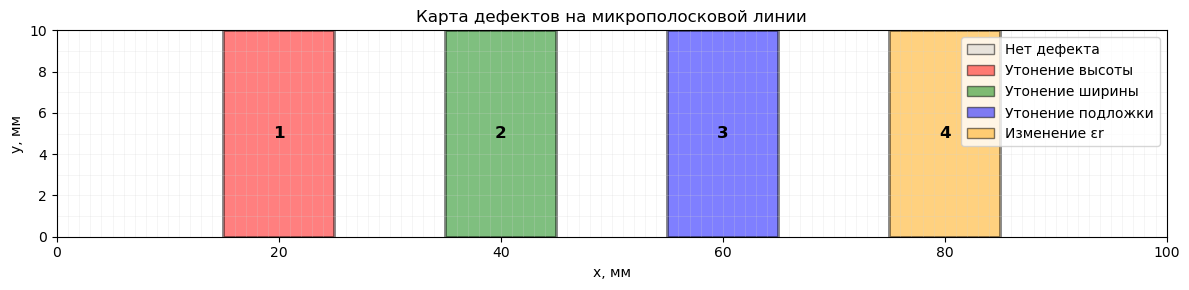

Карта сохранена в defect_map.png


In [219]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, L_line*1000)
ax.set_ylim(0, W_nom*1000)
ax.set_xlabel('x, мм')
ax.set_ylabel('y, мм')
ax.set_title('Карта дефектов на микрополосковой линии')

# Цвета для классов
colors = ['lightgray', 'red', 'green', 'blue', 'orange']
labels = ['Нет дефекта', 'Утонение высоты', 'Утонение ширины', 'Утонение подложки', 'Изменение εr']

# Сетка 1 мм
for x in np.arange(0, L_line*1000 + 1, 1):
    ax.axvline(x, color='lightgray', linewidth=0.5, linestyle='-', alpha=0.3)
for y in np.arange(0, W_nom*1000 + 1, 1):
    ax.axhline(y, color='lightgray', linewidth=0.5, linestyle='-', alpha=0.3)

# Прямоугольники дефектов
for defect, typ in zip(defects, types):
    x_left = defect.x1 * 1000
    width = defect.L_def * 1000
    rect = Rectangle((x_left, 0), width, W_nom*1000,
                     linewidth=2, edgecolor='black', facecolor=colors[typ], alpha=0.5)
    ax.add_patch(rect)
    ax.text(x_left + width/2, W_nom*1000/2, str(typ),
            ha='center', va='center', fontsize=12, color='black', weight='bold')

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.5, edgecolor='black', label=labels[i]) for i in range(5)]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('defect_map.png', dpi=150)
plt.show()
print("Карта сохранена в defect_map.png")

# Предварительный анализ сгенерированных данных

## Загрузка данных

In [220]:
df = pd.read_csv('mpl_scan_data.csv')
print(f"Загружено {len(df)} записей")
print("Распределение классов:")
print(df['class'].value_counts().sort_index())

Загружено 3800 записей
Распределение классов:
class
0.0    3520
1.0      70
2.0      70
3.0      70
4.0      70
Name: count, dtype: int64


## 1. Проверка физической адекватности

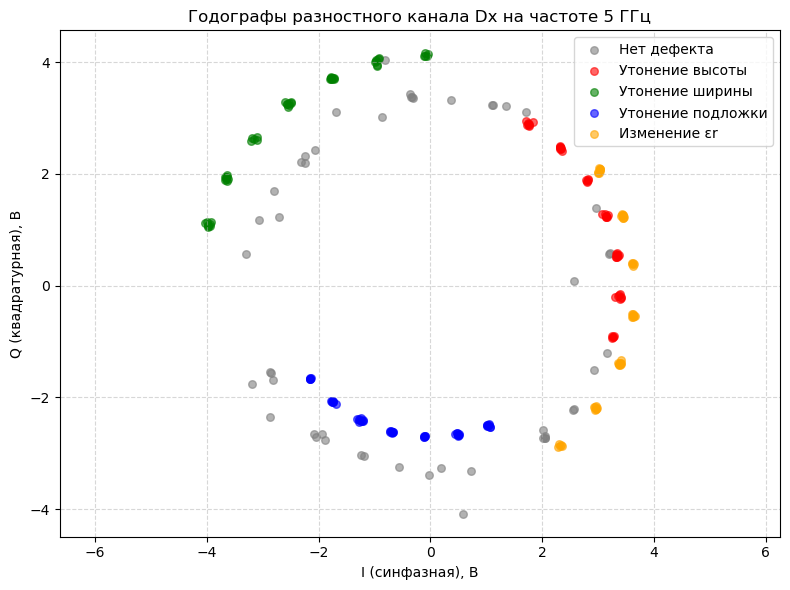

In [221]:
# Выбираем частоту 5 ГГц
freq = 5
col_I = f'I_Dx_{freq}GHz'
col_Q = f'Q_Dx_{freq}GHz'

# Для наглядности возьмём по 50 случайных точек из каждого класса (если их достаточно)
np.random.seed(42)
classes = sorted(df['class'].unique())
colors = ['gray', 'red', 'green', 'blue', 'orange']
labels = ['Нет дефекта', 'Утонение высоты', 'Утонение ширины', 'Утонение подложки', 'Изменение εr']

plt.figure(figsize=(8, 6))
for cls, color, label in zip(classes, colors[:len(classes)], labels):
    subset = df[df['class'] == cls]
    if len(subset) > 50:
        subset = subset.sample(50, random_state=42)
    I = subset[col_I].values
    Q = subset[col_Q].values
    plt.scatter(I, Q, color=color, alpha=0.6, label=label, s=30)

plt.xlabel('I (синфазная), В')
plt.ylabel('Q (квадратурная), В')
plt.title(f'Годографы разностного канала Dx на частоте {freq} ГГц')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.savefig('hodographs.png', dpi=150)
plt.show()


## 2. Визуализация разделения классов

 ### 2.1 Для каждой частоты отдельно (используем признаки I_Dx и Q_Dx)

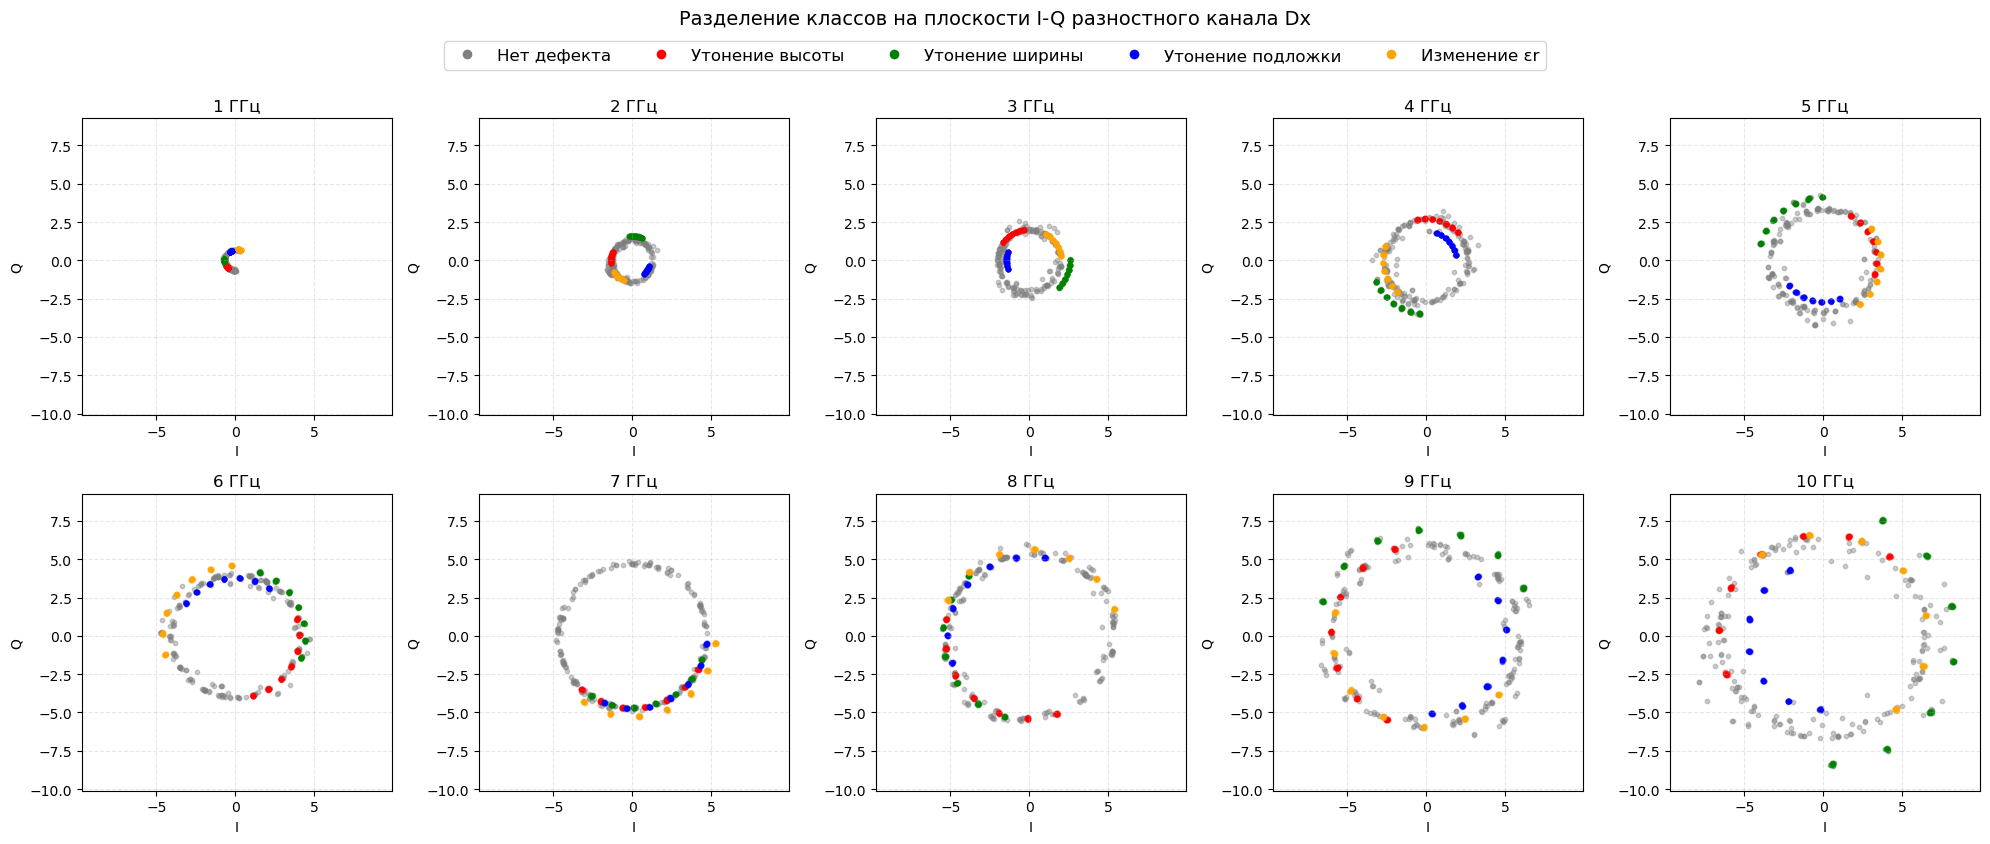

In [222]:
# Определим доступные частоты из названий столбцов (чтобы не задавать вручную)
freqs = sorted(set([int(col.split('_')[-1].replace('GHz', '')) 
                    for col in df.columns if col.endswith('GHz')]))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Для каждого графика вычислим общий разброс данных, чтобы установить адекватные пределы
all_I = []
all_Q = []
for f in freqs:
    col_I = f'I_Dx_{f}GHz'
    col_Q = f'Q_Dx_{f}GHz'
    all_I.extend(df[col_I].values)
    all_Q.extend(df[col_Q].values)
I_min, I_max = np.min(all_I), np.max(all_I)
Q_min, Q_max = np.min(all_Q), np.max(all_Q)
margin = 0.1 * max(I_max - I_min, Q_max - Q_min)

for i, f in enumerate(freqs):
    col_I = f'I_Dx_{f}GHz'
    col_Q = f'Q_Dx_{f}GHz'
    ax = axes[i]
    has_data = False
    for cls, color, label in zip(classes, colors[:len(classes)], labels):
        subset = df[df['class'] == cls]
        if len(subset) == 0:
            continue
        # Для наглядности возьмём не более 200 точек на класс
        if len(subset) > 200:
            subset = subset.sample(200, random_state=42)
        I = subset[col_I].values
        Q = subset[col_Q].values
        ax.scatter(I, Q, color=color, alpha=0.4, s=10, label=label if i == 0 else "")
        has_data = True
    ax.set_title(f'{f} ГГц')
    ax.set_xlabel('I')
    ax.set_ylabel('Q')
    ax.grid(True, linestyle='--', alpha=0.3)
    if has_data:
        ax.set_xlim(I_min - margin, I_max + margin)
        ax.set_ylim(Q_min - margin, Q_max + margin)

# Общая легенда
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=8, label=labels[i]) 
           for i in range(len(classes)) if len(df[df['class'] == i]) > 0]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=5, fontsize=12)

plt.suptitle('Разделение классов на плоскости I-Q разностного канала Dx', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig('per_frequency_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Общее изображение для всех частот (PCA всех признаков)

Доля объяснённой дисперсии двумя компонентами: 0.271


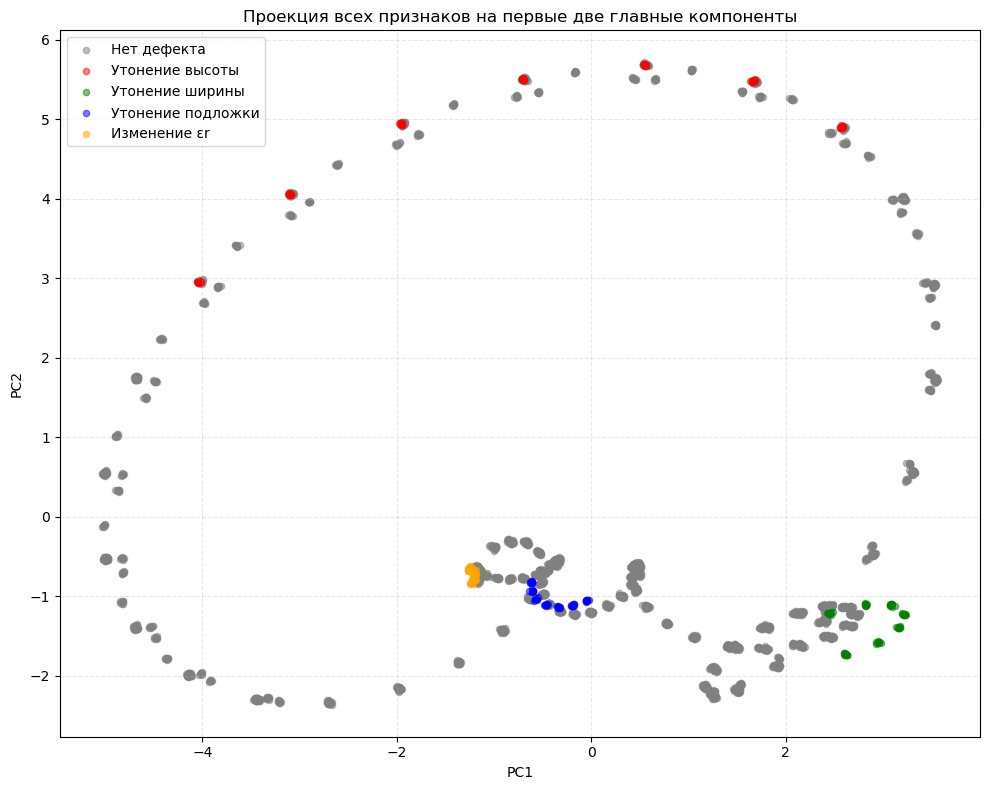

In [223]:
# Выделим все признаки (60 столбцов) и целевую переменную
feature_cols = [col for col in df.columns if col not in ['class', 'x_position']]
X = df[feature_cols].values
y = df['class'].values

# Стандартизация (важно для PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA до 2 компонент
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Доля объяснённой дисперсии двумя компонентами: {pca.explained_variance_ratio_.sum():.3f}")

# Визуализация
plt.figure(figsize=(10, 8))
for cls, color, label in zip(classes, colors[:len(classes)], labels):
    mask = (y == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, alpha=0.5, s=20, label=label)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Проекция всех признаков на первые две главные компоненты')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('pca_all_features.png', dpi=150)
plt.show()

## 3. Частотные зависимости

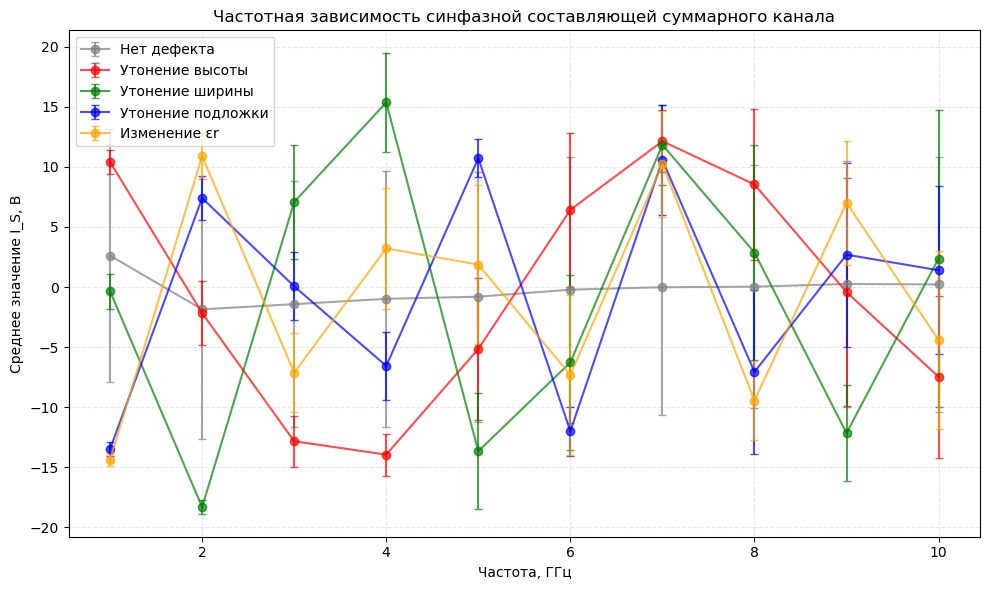

In [224]:
# Список частот (те же)
freqs = [1,2,3,4,5,6,7,8,9,10]

# Для каждого класса собираем средние значения I_S на каждой частоте
mean_I_S = {cls: [] for cls in classes}
std_I_S = {cls: [] for cls in classes}

for f in freqs:
    col = f'I_S_{f}GHz'
    for cls in classes:
        values = df[df['class'] == cls][col].values
        mean_I_S[cls].append(np.mean(values))
        std_I_S[cls].append(np.std(values))

# Построение графика
plt.figure(figsize=(10, 6))
for cls, color, label in zip(classes, colors[:len(classes)], labels):
    plt.errorbar(freqs, mean_I_S[cls], yerr=std_I_S[cls], color=color, marker='o', capsize=3, label=label, alpha=0.7)

plt.xlabel('Частота, ГГц')
plt.ylabel('Среднее значение I_S, В')
plt.title('Частотная зависимость синфазной составляющей суммарного канала')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('frequency_dependence.png', dpi=150)
plt.show()


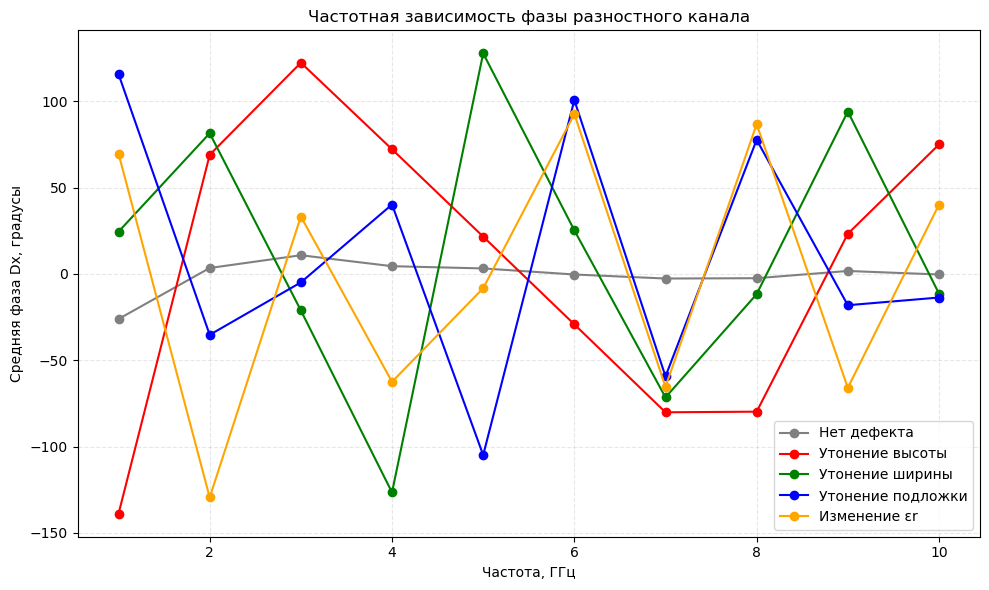

In [225]:
# Дополнительно: частотная зависимость фазы разностного канала Dx (угол комплексного числа)
plt.figure(figsize=(10, 6))
for cls, color, label in zip(classes, colors[:len(classes)], labels):
    phase_means = []
    for f in freqs:
        I = df[df['class'] == cls][f'I_Dx_{f}GHz'].values
        Q = df[df['class'] == cls][f'Q_Dx_{f}GHz'].values
        phase = np.angle(I + 1j*Q)  # в радианах
        phase_means.append(np.mean(phase))
    plt.plot(freqs, np.rad2deg(phase_means), marker='o', color=color, label=label)

plt.xlabel('Частота, ГГц')
plt.ylabel('Средняя фаза Dx, градусы')
plt.title('Частотная зависимость фазы разностного канала')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('phase_frequency.png', dpi=150)
plt.show()

# Обучение модели классификации (случайный лес)

## 1. Подготовка данных

In [226]:
print(f"Размер данных: {df.shape}")
print("Распределение классов:")
print(df['class'].value_counts().sort_index())

# Признаки и целевая переменная
feature_cols = [col for col in df.columns if col not in ['class', 'x_position']]
X = df[feature_cols].values
y = df['class'].values


Размер данных: (3800, 62)
Распределение классов:
class
0.0    3520
1.0      70
2.0      70
3.0      70
4.0      70
Name: count, dtype: int64


## 2. Разделение на обучающую, валидационную и тестовую выборки

In [227]:
# Сначала разделим на обучающую (70%) и временную (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Затем временную разделим на валидационную (15%) и тестовую (15%) от исходных
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (2660, 60)
Валидационная выборка: (570, 60)
Тестовая выборка: (570, 60)


## 3. Подбор гиперпараметров с помощью GridSearchCV


In [228]:
# Определяем базовую модель
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Сетка гиперпараметров
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 0.5]
}

# Кросс-валидация на обучающей выборке (5-fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший F1-macro на кросс-валидации: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}
Лучший F1-macro на кросс-валидации: 0.8753


## 4. Обучение финальной модели на объединённой обучающей и валидационной выборке

In [229]:
# Объединяем train и val для увеличения объёма обучения
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

# Обучаем модель с лучшими параметрами
best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train_full, y_train_full)

# Оценка на тестовой выборке
y_pred = best_rf.predict(X_test)
test_accuracy = np.mean(y_pred == y_test)
test_f1 = classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']

print(f"Точность на тесте: {test_accuracy:.4f}")
print(f"Macro F1 на тесте: {test_f1:.4f}")


Точность на тесте: 0.9807
Macro F1 на тесте: 0.8685


## 5. Матрица ошибок и отчёт по классификации


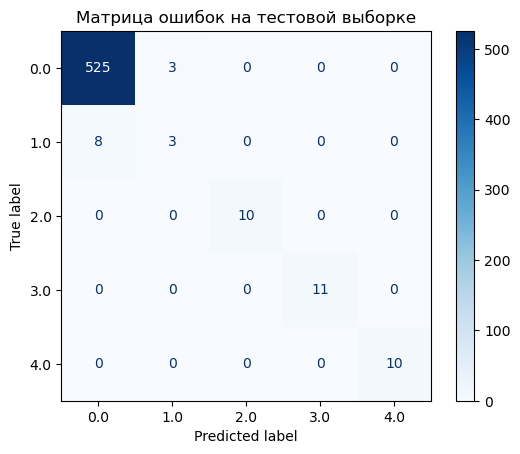

              precision    recall  f1-score   support

     Класс 0       0.98      0.99      0.99       528
     Класс 1       0.50      0.27      0.35        11
     Класс 2       1.00      1.00      1.00        10
     Класс 3       1.00      1.00      1.00        11
     Класс 4       1.00      1.00      1.00        10

    accuracy                           0.98       570
   macro avg       0.90      0.85      0.87       570
weighted avg       0.98      0.98      0.98       570



In [230]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок на тестовой выборке')
plt.show()

# Отчёт
print(classification_report(y_test, y_pred, target_names=[f'Класс {i}' for i in range(5)]))


## 6. Оценка важности признаков

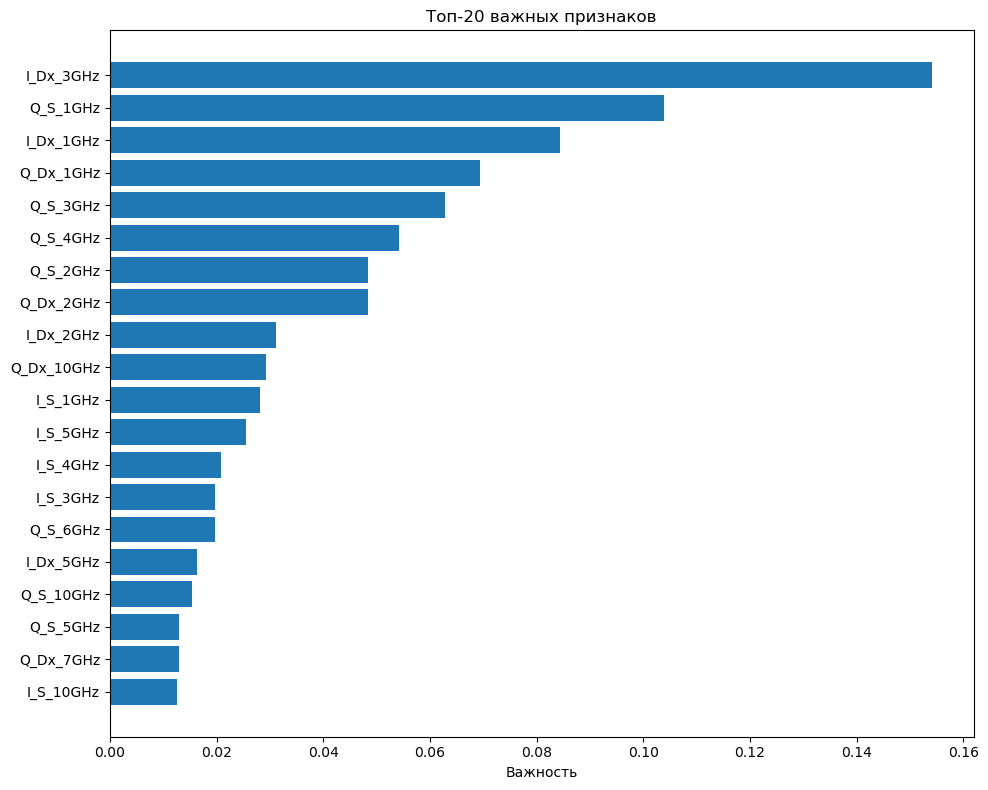

In [231]:
# Важность признаков из модели
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Построим горизонтальный барплот для топ-20 признаков
plt.figure(figsize=(10, 8))
plt.barh(range(min(20, len(feature_cols))), importances[indices[:20]], align='center')
plt.yticks(range(min(20, len(feature_cols))), [feature_cols[i] for i in indices[:20]])
plt.xlabel('Важность')
plt.title('Топ-20 важных признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Визуализация одного дерева из леса

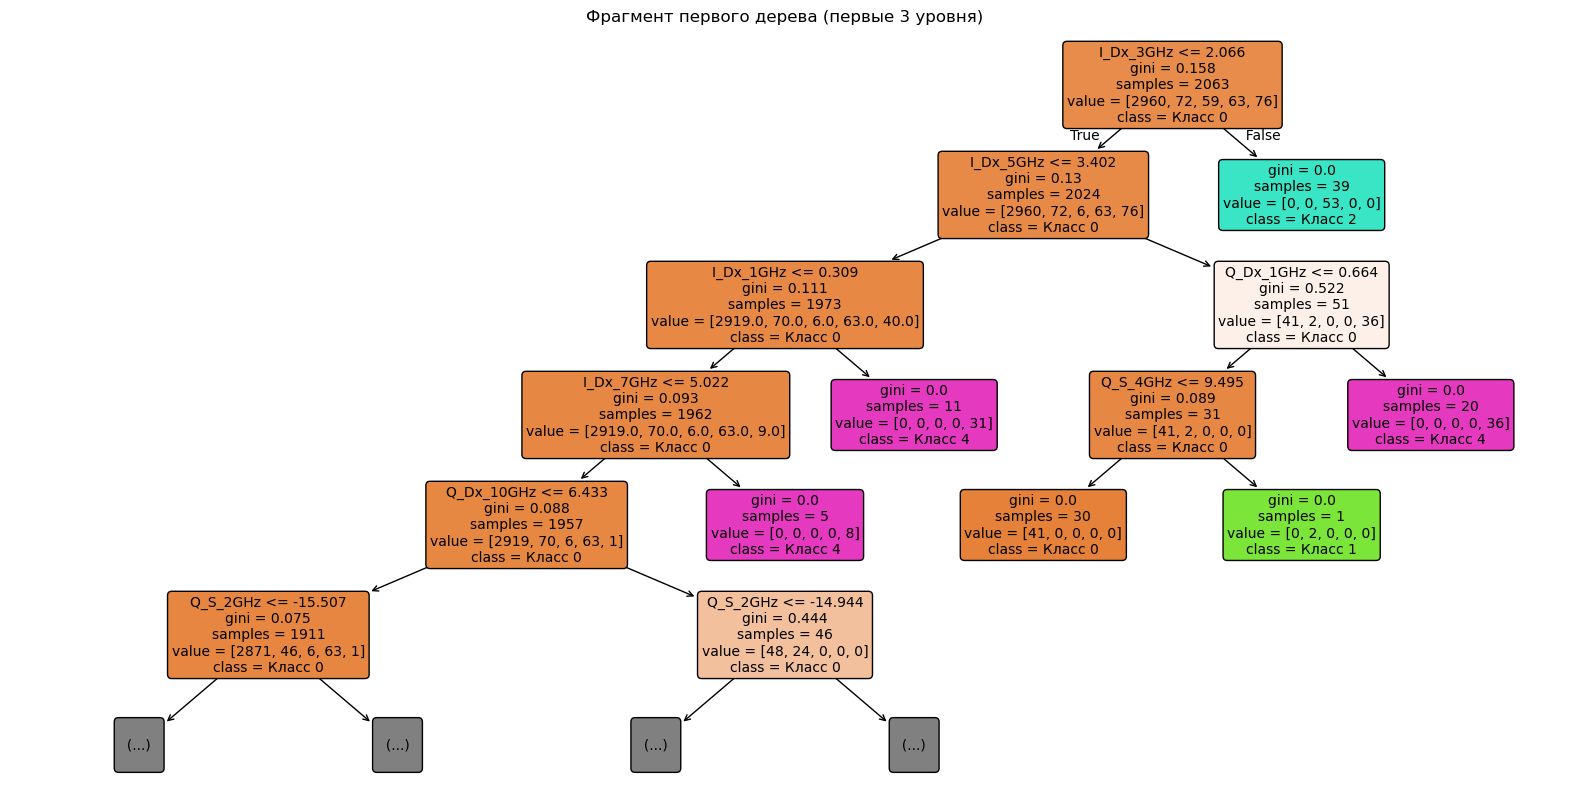

Глубина полного дерева: 14
Количество узлов в дереве: 69


In [232]:
# Возьмём первое дерево
first_tree = best_rf.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(first_tree, max_depth=5, feature_names=feature_cols, 
          class_names=[f'Класс {i}' for i in range(5)], 
          filled=True, rounded=True, fontsize=10)
plt.title('Фрагмент первого дерева (первые 3 уровня)')
plt.show()

# Выведем информацию о глубине дерева и количестве узлов
tree_depth = first_tree.tree_.max_depth
n_nodes = first_tree.tree_.node_count
print(f"Глубина полного дерева: {tree_depth}")
print(f"Количество узлов в дереве: {n_nodes}")


## 8. (Дополнительно) Сохранение модели для последующего использования

In [233]:
joblib.dump(best_rf, 'random_forest_model.pkl')
print("Модель сохранена как random_forest_model.pkl")

Модель сохранена как random_forest_model.pkl


# Оценка качества классификации

## 1. Подготовка тестовых данных с координатами

In [234]:
# Выделяем признаки и позиции
feature_cols = [col for col in df.columns if col not in ['class', 'x_position']]
X = df[feature_cols].values
y = df['class'].values
positions = df['x_position'].values

# Разделяем на train и temp (70/30) с сохранением индексов
X_train, X_temp, y_train, y_temp, pos_train, pos_temp = train_test_split(
    X, y, positions, test_size=0.3, random_state=42, stratify=y
)

# Разделяем temp на val и test (50/50)
X_val, X_test, y_val, y_test, pos_val, pos_test = train_test_split(
    X_temp, y_temp, pos_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Тестовая выборка: {X_test.shape}, позиций: {len(pos_test)}")

Тестовая выборка: (570, 60), позиций: 570


## 2. Предсказание и матрица ошибок

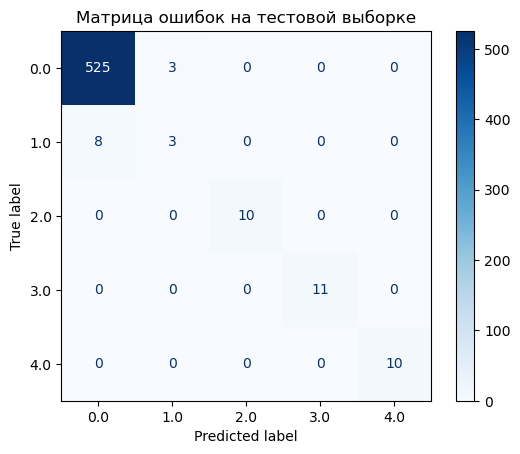

In [235]:
# Предсказание (используем уже обученную модель best_rf)
y_pred = best_rf.predict(X_test)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок на тестовой выборке')
plt.show()

## 3. Числовые метрики

In [236]:
# Общая точность
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

# Метрики по классам
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

print("\nМетрики по классам:")
for i in range(5):
    print(f"Класс {i}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}, Support={support[i]}")

# Макро-усреднённые
print(f"\nMacro Precision: {np.mean(precision):.4f}")
print(f"Macro Recall: {np.mean(recall):.4f}")
print(f"Macro F1: {np.mean(f1):.4f}")

# Отчёт классификации
print("\nПолный отчёт:")
print(classification_report(y_test, y_pred, target_names=[f'Класс {i}' for i in range(5)]))


Accuracy: 0.9807

Метрики по классам:
Класс 0: Precision=0.9850, Recall=0.9943, F1=0.9896, Support=528
Класс 1: Precision=0.5000, Recall=0.2727, F1=0.3529, Support=11
Класс 2: Precision=1.0000, Recall=1.0000, F1=1.0000, Support=10
Класс 3: Precision=1.0000, Recall=1.0000, F1=1.0000, Support=11
Класс 4: Precision=1.0000, Recall=1.0000, F1=1.0000, Support=10

Macro Precision: 0.8970
Macro Recall: 0.8534
Macro F1: 0.8685

Полный отчёт:
              precision    recall  f1-score   support

     Класс 0       0.98      0.99      0.99       528
     Класс 1       0.50      0.27      0.35        11
     Класс 2       1.00      1.00      1.00        10
     Класс 3       1.00      1.00      1.00        11
     Класс 4       1.00      1.00      1.00        10

    accuracy                           0.98       570
   macro avg       0.90      0.85      0.87       570
weighted avg       0.98      0.98      0.98       570



## 4. Карта дефектов до и после классификации

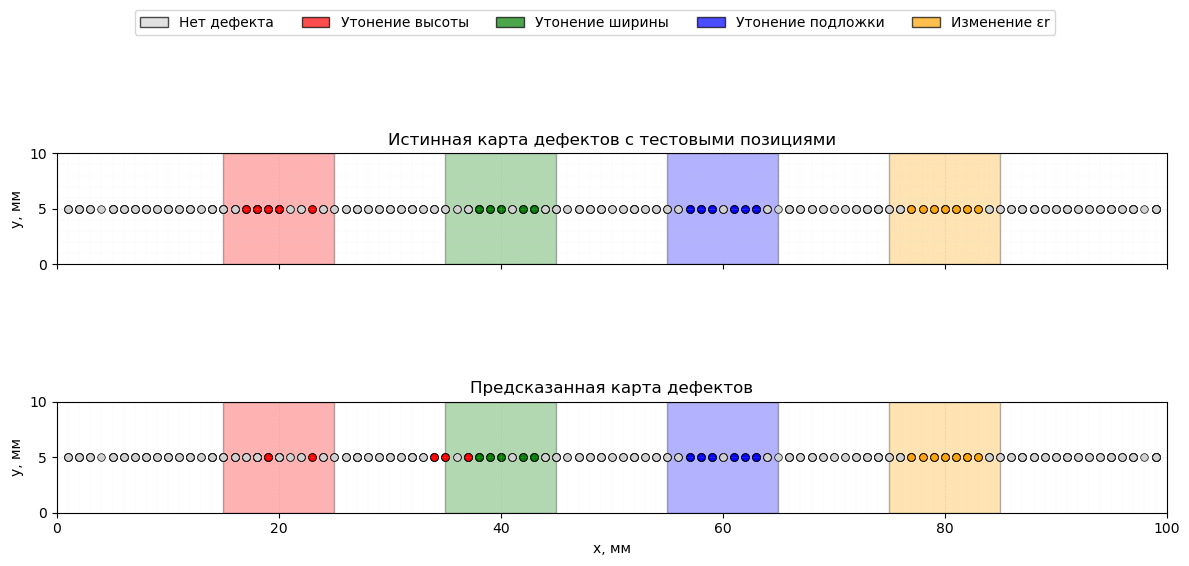

In [238]:
# Параметры линии
L_line = 0.1          # 10 см
W_nom = 0.01          # 1 см

# Цвета для классов
colors = ['lightgray', 'red', 'green', 'blue', 'orange']
labels = ['Нет дефекта', 'Утонение высоты', 'Утонение ширины', 'Утонение подложки', 'Изменение εr']

# Если переменные defects и types не определены в текущей сессии, пересоздаём их (как при генерации)
if 'defects' not in globals():
    # Параметры линии (те же, что использовались при генерации)
    W_nom = 0.01
    h_nom = 0.5e-3
    t_nom = 35e-6
    eps_nom = 4.5
    parent = MicrostripLine(W=W_nom, h=h_nom, t=t_nom, epsilon_r=eps_nom)
    
    # Параметры дефектов
    x_centers = [0.02, 0.04, 0.06, 0.08]
    L_def = 0.01
    types = [1, 2, 3, 4]
    
    t1 = t_nom * 0.7
    W2 = W_nom * 0.7
    h3 = h_nom * 0.7
    eps4 = eps_nom * 1.3
    
    defects = [
        Defect(parent, W_nom, h_nom, t1, eps_nom, x_centers[0], L_def),
        Defect(parent, W2, h_nom, t_nom, eps_nom, x_centers[1], L_def),
        Defect(parent, W_nom, h3, t_nom, eps_nom, x_centers[2], L_def),
        Defect(parent, W_nom, h_nom, t_nom, eps4, x_centers[3], L_def)
    ]

# Создаём фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Настройка осей
for ax in (ax1, ax2):
    ax.set_xlim(0, L_line*1000)
    ax.set_ylim(0, W_nom*1000)
    ax.set_ylabel('y, мм')
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

ax2.set_xlabel('x, мм')
ax1.set_title('Истинная карта дефектов с тестовыми позициями')
ax2.set_title('Предсказанная карта дефектов')

# Рисуем прямоугольники дефектов на обоих графиках (отдельные копии)
for defect, typ in zip(defects, types):
    x_left = defect.x1 * 1000
    width = defect.L_def * 1000
    # Прямоугольник для первого графика
    rect1 = Rectangle((x_left, 0), width, W_nom*1000,
                      linewidth=1, edgecolor='black', facecolor=colors[typ], alpha=0.3)
    ax1.add_patch(rect1)
    # Прямоугольник для второго графика (новая копия)
    rect2 = Rectangle((x_left, 0), width, W_nom*1000,
                      linewidth=1, edgecolor='black', facecolor=colors[typ], alpha=0.3)
    ax2.add_patch(rect2)

# Добавляем сетку 1 мм (для красоты)
for x in np.arange(0, L_line*1000 + 1, 1):
    ax1.axvline(x, color='lightgray', linewidth=0.3, alpha=0.2)
    ax2.axvline(x, color='lightgray', linewidth=0.3, alpha=0.2)
for y in np.arange(0, W_nom*1000 + 1, 1):
    ax1.axhline(y, color='lightgray', linewidth=0.3, alpha=0.2)

# Отмечаем тестовые позиции (центры головки)
# Истинные классы
for cls in range(5):
    mask = (y_test == cls)
    ax1.scatter(pos_test[mask]*1000, [W_nom*1000/2]*np.sum(mask), 
                color=colors[cls], s=30, edgecolor='black', linewidth=0.5, label=labels[cls] if cls==0 else "")

# Предсказанные классы
for cls in range(5):
    mask = (y_pred == cls)
    ax2.scatter(pos_test[mask]*1000, [W_nom*1000/2]*np.sum(mask), 
                color=colors[cls], s=30, edgecolor='black', linewidth=0.5, label=labels[cls] if cls==0 else "")

# Легенда (общая)
handles = [Patch(facecolor=colors[i], edgecolor='black', alpha=0.7, label=labels[i]) for i in range(5)]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5, fontsize=10)

plt.tight_layout()
plt.savefig('defect_map_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Генерация итогового отчёта

In [240]:
# Собираем результаты
best_params = grid_search.best_params_
accuracy = np.mean(y_pred == y_test)
macro_f1 = classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

# Важность признаков (топ-10)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
top_features = [(feature_cols[i], importances[i]) for i in indices]

# Формируем текст отчёта
report_lines = []
report_lines.append("="*60)
report_lines.append("ОТЧЁТ О КЛАССИФИКАЦИИ ДЕФЕКТОВ МИКРОПОЛОСКОВОЙ ЛИНИИ")
report_lines.append(f"Дата и время: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("="*60)

report_lines.append("\n1. ПАРАМЕТРЫ МОДЕЛИ")
report_lines.append(f"   Лучшие гиперпараметры (GridSearchCV):")
for k, v in best_params.items():
    report_lines.append(f"      {k}: {v}")

report_lines.append(f"\n   Размер обучающей выборки: {X_train_full.shape[0]}")
report_lines.append(f"   Размер тестовой выборки: {X_test.shape[0]}")

report_lines.append("\n2. МЕТРИКИ КЛАССИФИКАЦИИ")
report_lines.append(f"   Accuracy на тесте: {accuracy:.4f}")
report_lines.append(f"   Macro F1 на тесте: {macro_f1:.4f}\n")
report_lines.append("   Метрики по классам:")
report_lines.append("   Класс  Precision  Recall  F1     Support")
for i in range(5):
    report_lines.append(f"   {i:5d}  {precision[i]:.4f}    {recall[i]:.4f}   {f1[i]:.4f}   {support[i]:5d}")

report_lines.append("\n3. ВАЖНОСТЬ ПРИЗНАКОВ (ТОП-10)")
for i, (name, imp) in enumerate(top_features, 1):
    report_lines.append(f"   {i:2d}. {name:30s} : {imp:.4f}")

report_lines.append("\n4. МАТРИЦА ОШИБОК")
report_lines.append(str(confusion_matrix(y_test, y_pred)))

report_lines.append("\n" + "="*60)
report_lines.append("КОНЕЦ ОТЧЁТА")
report_lines.append("="*60)

# Выводим в консоль и сохраняем в файл
report_text = "\n".join(report_lines)
print(report_text)

with open("classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nОтчёт сохранён в файл 'classification_report.txt'")

# Дополнительно сохраняем изображения, если нужно
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Матрица ошибок
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок')
plt.savefig('confusion_matrix.png', dpi=150)
plt.close()

# Важность признаков (диаграмма)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), [imp for _, imp in top_features][::-1], align='center')
plt.yticks(range(len(top_features)), [name for name, _ in top_features][::-1])
plt.xlabel('Важность')
plt.title('Топ-10 важных признаков')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.close()

print("Графики сохранены: confusion_matrix.png, feature_importance.png")

ОТЧЁТ О КЛАССИФИКАЦИИ ДЕФЕКТОВ МИКРОПОЛОСКОВОЙ ЛИНИИ
Дата и время: 2026-03-02 13:25:52

1. ПАРАМЕТРЫ МОДЕЛИ
   Лучшие гиперпараметры (GridSearchCV):
      max_depth: 20
      max_features: 0.5
      min_samples_leaf: 1
      n_estimators: 200

   Размер обучающей выборки: 3230
   Размер тестовой выборки: 570

2. МЕТРИКИ КЛАССИФИКАЦИИ
   Accuracy на тесте: 0.9807
   Macro F1 на тесте: 0.8685

   Метрики по классам:
   Класс  Precision  Recall  F1     Support
       0  0.9850    0.9943   0.9896     528
       1  0.5000    0.2727   0.3529      11
       2  1.0000    1.0000   1.0000      10
       3  1.0000    1.0000   1.0000      11
       4  1.0000    1.0000   1.0000      10

3. ВАЖНОСТЬ ПРИЗНАКОВ (ТОП-10)
    1. I_Dx_3GHz                      : 0.1542
    2. Q_S_1GHz                       : 0.1038
    3. I_Dx_1GHz                      : 0.0844
    4. Q_Dx_1GHz                      : 0.0693
    5. Q_S_3GHz                       : 0.0629
    6. Q_S_4GHz                       : 0.0542
    